# 📈 Churn-specific metrics — Lift, Gain, Calibration, Business Impact

**Why this notebook exists.** ROC-AUC and precision/recall (from notebook 3) tell us the model can rank churners above non-churners. But in a real churn-retention campaign you can only afford to **contact a limited number of customers**. The questions you actually have to answer are:

- If I can call the top 10% of my scored customers, what fraction of real churners do I catch?
- How much better is the model than picking 10% at random?
- Are the model's probabilities trustworthy enough to use as expected churn rates?
- For a given retention-offer budget, what's the expected return?

These are the metrics that translate model performance into business decisions.

## What we'll compute

| Metric | What it answers |
|---|---|
| **Decile table** | Per top-10% slice: how many churners, what threshold, what rate |
| **Lift @ top K%** | At top K%, how many churners do we catch vs. random (multiplier) |
| **Gain @ top K%** | At top K%, what fraction of *all* churners do we capture |
| **Cumulative gains curve** | Gain plotted across all K |
| **Lift curve** | Lift plotted across all K |
| **KS statistic** | Max separation between churners and non-churners in score distribution |
| **Brier score + calibration curve** | Are the probabilities themselves trustworthy? |
| **Expected value** | $ won by contacting the top K% (parametric on offer cost + LTV) |


## Imports & config

In [1]:
import os
import json
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve

# Pull shared dataset config from Module 2
sys.path.insert(0, '../2. Training')
from training_config import TARGET_COL, ID_COLS

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

print('✓ Libraries imported')

✓ Libraries imported


## 1. Load the trained model and the test set

We use the **test set** here (not validation) — the metrics in this notebook are how you'd report final, unbiased performance to the business.

The model and the threshold come from Module 2's `model_selection_output/`.

In [2]:
MODEL_DIR = '../2. Training/model_selection_output'
DATA_DIR  = '../2. Training/data_preparation_output'

# Pick whichever model won in Module 2
model_path = None
for name in ('catboost_model.pkl', 'xgboost_model.pkl'):
    if os.path.exists(f'{MODEL_DIR}/{name}'):
        model_path = f'{MODEL_DIR}/{name}'
        break
assert model_path, 'No trained model found — run Module 2 first.'

with open(model_path, 'rb') as f:
    model = pickle.load(f)
with open(f'{MODEL_DIR}/results.json') as f:
    results = json.load(f)
threshold = results['threshold']

print(f"✓ Loaded model: {model_path}")
print(f"  Tuned threshold (from Module 2): {threshold:.3f}")

# Load test set (already cleaned by Module 2)
test_df = pd.read_parquet(f'{DATA_DIR}/test.parquet')

# Drop the same ID columns Module 2 dropped, plus any datetime columns
to_drop = [c for c in ID_COLS if c in test_df.columns]
to_drop += test_df.select_dtypes(include='datetime64').columns.tolist()
X_test = test_df.drop(columns=to_drop + [TARGET_COL])
y_test = test_df[TARGET_COL].values

# Score every test customer
y_score = model.predict_proba(X_test)[:, 1]

print(f"\n✓ Test set scored:")
print(f"  {len(y_test):,} customers")
print(f"  {int(y_test.sum()):,} actual churners ({y_test.mean():.1%})")
print(f"  Score range: {y_score.min():.3f} → {y_score.max():.3f}")

✓ Loaded model: ../2. Training/model_selection_output/catboost_model.pkl
  Tuned threshold (from Module 2): 0.292

✓ Test set scored:
  10,340 customers
  3,617 actual churners (35.0%)
  Score range: 0.005 → 0.893


## 2. Decile table — the foundation

Sort customers by predicted churn score (high → low), split into 10 equal-size buckets ("deciles"), and look at how many real churners landed in each.

If the model is useless: each decile holds ~10% of the churners.\
If the model is good: the top decile is dense with churners, the bottom decile is empty.

This single table is the backbone of every other metric in this notebook.

In [3]:
def decile_table(y_true, y_score, n_bins=10):
    """Sort by score desc, split into n_bins equal-size groups, summarize each."""
    df = pd.DataFrame({'true': y_true, 'score': y_score})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(np.arange(len(df)), n_bins, labels=range(1, n_bins + 1))

    table = df.groupby('decile', observed=True).agg(
        n_customers   = ('true',  'size'),
        n_churners    = ('true',  'sum'),
        churn_rate    = ('true',  'mean'),
        score_min     = ('score', 'min'),
        score_max     = ('score', 'max'),
    )
    # Cumulative gain = fraction of all churners captured by the top K deciles
    table['cum_gain']  = table['n_churners'].cumsum() / y_true.sum()
    # Cumulative lift = (cum churn rate in top K deciles) / (base churn rate)
    cum_customers      = table['n_customers'].cumsum()
    cum_churners       = table['n_churners'].cumsum()
    base_rate          = y_true.mean()
    table['cum_lift']  = (cum_churners / cum_customers) / base_rate
    return table

table = decile_table(y_test, y_score)
table

,n_customers,n_churners,churn_rate,score_min,score_max,cum_gain,cum_lift
decile,,,,,,,
1,1034,765,0.740,0.641,0.893,0.212,2.115
2,1034,648,0.627,0.519,0.641,0.391,1.953
3,1034,538,0.520,0.427,0.519,0.539,1.798
4,1034,448,0.433,0.350,0.427,0.663,1.658
5,1034,396,0.383,0.276,0.350,0.773,1.545
6,1034,289,0.279,0.208,0.276,0.853,1.421
7,1034,228,0.221,0.150,0.208,0.916,1.308
8,1034,149,0.144,0.099,0.150,0.957,1.196
9,1034,100,0.097,0.058,0.099,0.985,1.094


## 3. Lift and gain at the top **K%**

Deciles are coarse. In practice, you might want "top 5%" or "top 7%" — whatever your retention team can actually contact. Two definitions:

- **Gain @ K%** = `(churners in top K%) / (all churners)` — the fraction of churn you'd *catch* by contacting K% of customers.
- **Lift @ K%** = `(churn rate in top K%) / (overall churn rate)` — how much more churn-dense the top K% is than a random K%.

A lift of `3.0` means: "if I call the top 10%, 3× more of those people are real churners than a random 10% would have been."

In [4]:
def lift_gain_at_top_k(y_true, y_score, k_fraction):
    """Compute lift and gain at the top k_fraction of the score distribution."""
    n = len(y_true)
    n_top = max(1, int(np.ceil(n * k_fraction)))
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    n_pos_top   = int(y_sorted[:n_top].sum())
    n_pos_total = int(y_true.sum())
    base_rate   = n_pos_total / n

    return {
        'k_pct':         k_fraction,
        'n_contacted':   n_top,
        'churners_caught': n_pos_top,
        'gain':          n_pos_top / n_pos_total,
        'lift':          (n_pos_top / n_top) / base_rate,
    }

k_values = [0.05, 0.10, 0.20, 0.30, 0.50]
summary = pd.DataFrame([lift_gain_at_top_k(y_test, y_score, k) for k in k_values])
summary['k_pct']  = summary['k_pct'].map(lambda v: f'top {v:.0%}')
summary['gain']   = summary['gain'].map('{:.1%}'.format)
summary['lift']   = summary['lift'].map('{:.2f}×'.format)
print(summary.to_string(index=False))

print('\n💡 How to read this:')
print('  • "gain" tells the retention team what coverage they get for each level of effort.')
print('  • "lift" tells them how much the model beats a random-call campaign.')

# Worked example for the top 5% — numbers come from the same helper used above,
# so the sentence stays in sync if the test set or model change.
ex = lift_gain_at_top_k(y_test, y_score, 0.05)
total_churners = int(y_test.sum())
print(f"\n📖 Reading the 'top 5%' row out loud:")
print(f"   We rank all {len(y_test):,} customers by model score, highest first.")
print(f"   If retention contacts the top 5% — that's {ex['n_contacted']:,} people — they")
print(f"   reach {ex['churners_caught']:,} real churners, which is {ex['gain']:.1%} of the {total_churners:,}")
print(f"   churners in the whole test set (gain). That's {ex['lift']:.2f}× more churners")
print(f"   than they'd catch by phoning {ex['n_contacted']:,} customers at random (lift).")

  k_pct  n_contacted  churners_caught  gain  lift
 top 5%          517              402 11.1% 2.22×
top 10%         1034              765 21.2% 2.12×
top 20%         2068             1413 39.1% 1.95×
top 30%         3102             1951 53.9% 1.80×
top 50%         5170             2795 77.3% 1.55×

💡 How to read this:
  • "gain" tells the retention team what coverage they get for each level of effort.
  • "lift" tells them how much the model beats a random-call campaign.

📖 Reading the 'top 5%' row out loud:
   We rank all 10,340 customers by model score, highest first.
   If retention contacts the top 5% — that's 517 people — they
   reach 402 real churners, which is 11.1% of the 3,617
   churners in the whole test set (gain). That's 2.22× more churners
   than they'd catch by phoning 517 customers at random (lift).


## 4. Cumulative gains and lift curves

Same idea as the table above, but plotted continuously — pick any operating point that matches your campaign budget.

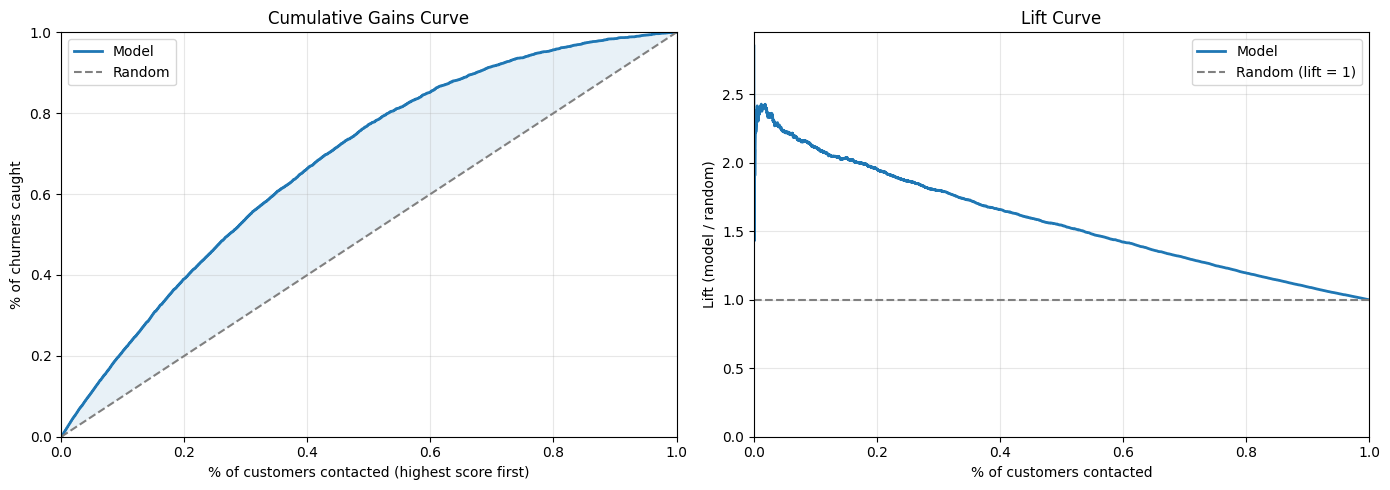

💡 The gains curve climbs steeply at first then flattens — that's the model.
   The straight diagonal is what you'd get from random calls.
   The gap between the two is the value the model adds.


In [5]:
order = np.argsort(-y_score)
y_sorted = y_test[order]
n = len(y_sorted)

k_grid = np.arange(1, n + 1) / n                 # fraction of customers contacted
gain   = np.cumsum(y_sorted) / y_sorted.sum()    # fraction of churners captured
lift   = gain / k_grid                           # multiplier vs. random

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative gains
axes[0].plot(k_grid, gain, lw=2, label='Model')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].fill_between(k_grid, k_grid, gain, alpha=0.1)
axes[0].set_xlabel('% of customers contacted (highest score first)')
axes[0].set_ylabel('% of churners caught')
axes[0].set_title('Cumulative Gains Curve')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3); axes[0].legend()

# Lift
axes[1].plot(k_grid, lift, lw=2, label='Model')
axes[1].axhline(1.0, ls='--', color='gray', label='Random (lift = 1)')
axes[1].set_xlabel('% of customers contacted')
axes[1].set_ylabel('Lift (model / random)')
axes[1].set_title('Lift Curve')
axes[1].set_xlim(0, 1); axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 The gains curve climbs steeply at first then flattens — that\'s the model.')
print('   The straight diagonal is what you\'d get from random calls.')
print('   The gap between the two is the value the model adds.')

## 5. KS statistic — one-number model power

The **Kolmogorov–Smirnov** statistic is the maximum vertical gap between the cumulative score distribution of *churners* and *non-churners*. If it's high, the two populations are well separated; if it's low, the model can't tell them apart.

Banks and telecom report this number a lot because it summarizes "how well does my score separate good from bad" in a single value.

KS statistic: 0.420 at score threshold 0.276
  → at this threshold, the model catches 77% of churners and wrongly flags 35% of non-churners


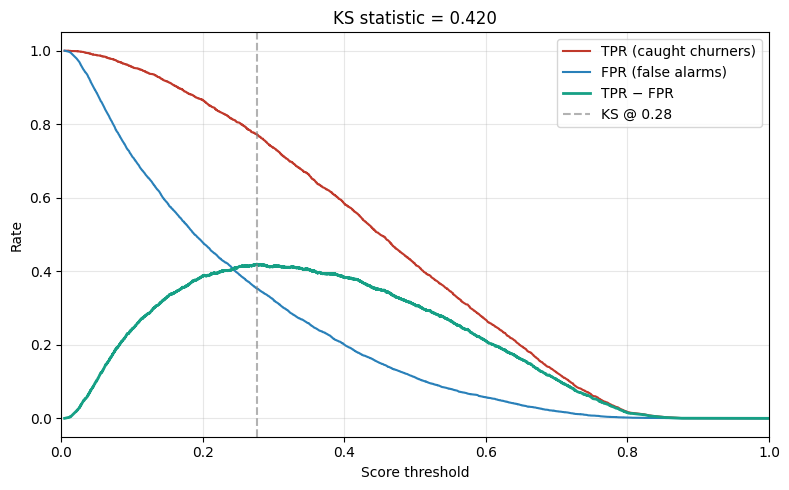


💡 Rough scale (industry conventions):
   KS < 0.20  weak     |  0.20–0.40 ok  |  0.40–0.60 good  |  > 0.60 excellent


In [6]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_score)

# sklearn's roc_curve sets thresholds_roc[0] = +inf as a convention to make
# the curve start at (0,0). Clip it to 1.0 so the x-axis in the plot stays in
# [0, 1]. (The KS argmax below isn't affected — at that point tpr == fpr == 0
# so the diff is 0 and won't win.)
thresholds_roc = np.clip(thresholds_roc, 0.0, 1.0)
ks_diff = tpr - fpr
ks_idx  = ks_diff.argmax()
ks_stat = ks_diff[ks_idx]
ks_threshold = thresholds_roc[ks_idx]

print(f'KS statistic: {ks_stat:.3f} at score threshold {ks_threshold:.3f}')
print(f'  → at this threshold, the model catches {tpr[ks_idx]:.0%} of churners and '
      f'wrongly flags {fpr[ks_idx]:.0%} of non-churners')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds_roc, tpr, label='TPR (caught churners)',     color='#c0392b')
ax.plot(thresholds_roc, fpr, label='FPR (false alarms)',         color='#2980b9')
ax.plot(thresholds_roc, ks_diff, label='TPR − FPR', color='#16a085', lw=2)
ax.axvline(ks_threshold, color='gray', ls='--', alpha=0.6, label=f'KS @ {ks_threshold:.2f}')
ax.set_xlabel('Score threshold')
ax.set_ylabel('Rate')
ax.set_title(f'KS statistic = {ks_stat:.3f}')
ax.set_xlim(0, 1); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print('\n💡 Rough scale (industry conventions):')
print('   KS < 0.20  weak     |  0.20–0.40 ok  |  0.40–0.60 good  |  > 0.60 excellent')

## 6. Are the probabilities trustworthy? — calibration + Brier score

ROC-AUC and lift only care about the *ranking* of scores. They tell you nothing about whether a customer with score `0.70` actually churns 70% of the time.

If you ever multiply the score by a dollar amount (expected revenue at risk, expected return on a retention offer), you need calibration. Two tools:

- **Brier score** — mean squared error between predicted probability and 0/1 outcome. Lower is better. 0 is perfect, 0.25 is a coin flip.
- **Reliability diagram** — plot predicted probability against observed frequency. Perfect calibration sits on the diagonal.

Brier score: 0.1806  (lower is better; 0.25 = random)


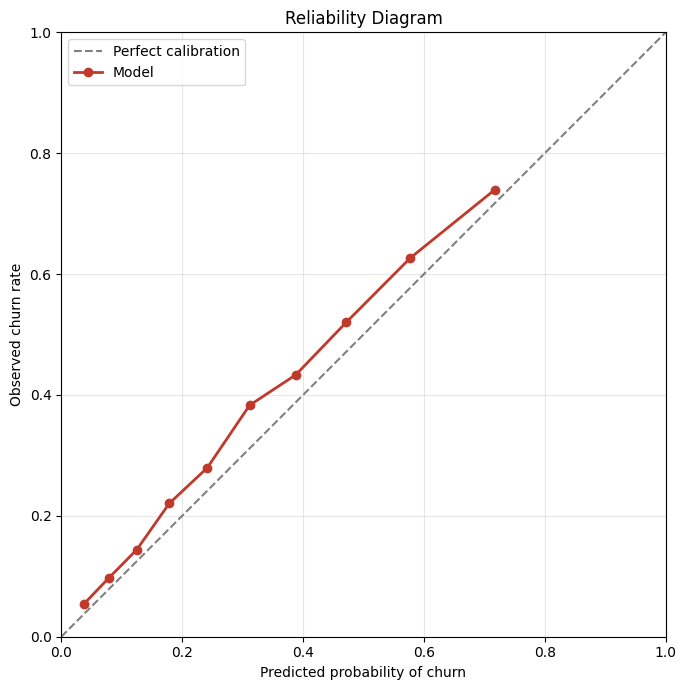


💡 If the red curve sits below the diagonal, the model OVER-predicts churn.
   If it sits above, the model UNDER-predicts churn.
   Big sag → re-calibrate (Platt scaling or isotonic regression) before using scores as $.


In [7]:
brier = brier_score_loss(y_test, y_score)
prob_true, prob_pred = calibration_curve(y_test, y_score, n_bins=10, strategy='quantile')

print(f'Brier score: {brier:.4f}  (lower is better; 0.25 = random)')

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', lw=2, color='#c0392b', label='Model')
ax.set_xlabel('Predicted probability of churn')
ax.set_ylabel('Observed churn rate')
ax.set_title('Reliability Diagram')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print('\n💡 If the red curve sits below the diagonal, the model OVER-predicts churn.')
print('   If it sits above, the model UNDER-predicts churn.')
print('   Big sag → re-calibrate (Platt scaling or isotonic regression) before using scores as $.')

## 7. Expected value — putting numbers on the campaign

Pretend the retention team gives us three numbers:

| Variable | What it means | Example value |
|---|---|---|
| `LTV` | Lifetime value saved when a real churner is retained | **€80** |
| `OFFER_COST` | Cost of sending one retention offer (call + discount) | **€5** |
| `CONVERSION_RATE` | Of contacted real churners, what % accept the offer | **30%** |

Then, for each top K%, expected value is roughly:

```
EV(K) = churners_caught(K) · CONVERSION_RATE · LTV  −  contacted(K) · OFFER_COST
```

The K with the highest EV is where the retention team should set the cutoff. Sweep all K and pick the maximum.

💰 Best operating point:
   Contact top 61.5% of customers (6,357 people)
   Catch 3,135 real churners (lift 1.41×)
   Expected value: €43,455


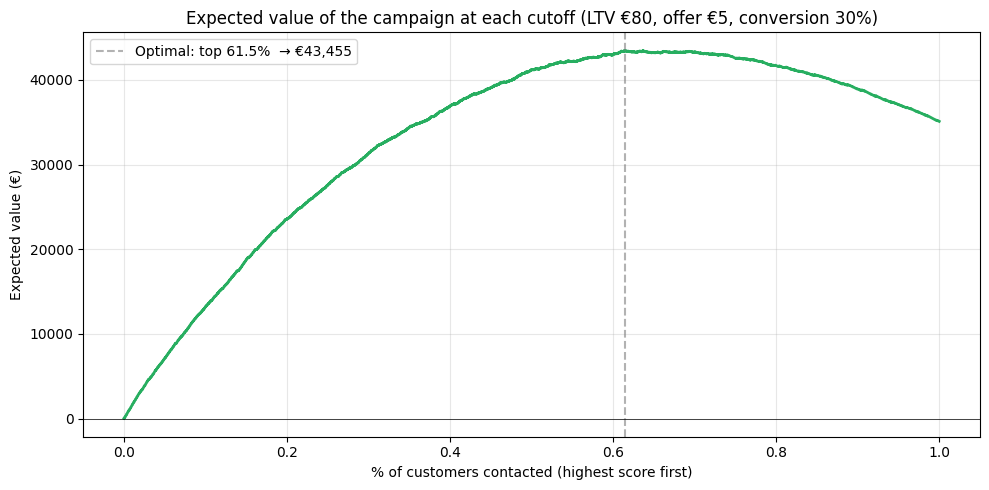


💡 Try editing LTV / OFFER_COST / CONVERSION_RATE above and re-running:
   the optimal cutoff is very sensitive to these. It is the *business* numbers,
   not the model, that ultimately decide how aggressive your campaign should be.


In [8]:
# Edit these to match your business — outputs adapt automatically
LTV             = 80    # € saved per retained churner
OFFER_COST      = 5     # € to contact one customer
CONVERSION_RATE = 0.30  # fraction of contacted churners who accept

n_contacted      = np.arange(1, n + 1)
churners_caught  = np.cumsum(y_sorted)        # cumulative true positives
ev = churners_caught * CONVERSION_RATE * LTV - n_contacted * OFFER_COST

best_idx  = ev.argmax()
best_k    = n_contacted[best_idx] / n
best_ev   = ev[best_idx]
best_caught = int(churners_caught[best_idx])

print(f'💰 Best operating point:')
print(f'   Contact top {best_k:.1%} of customers ({n_contacted[best_idx]:,} people)')
print(f'   Catch {best_caught:,} real churners (lift {lift[best_idx]:.2f}×)')
print(f'   Expected value: €{best_ev:,.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_contacted / n, ev, color='#27ae60', lw=2)
ax.axvline(best_k, ls='--', color='gray', alpha=0.6,
           label=f'Optimal: top {best_k:.1%}  → €{best_ev:,.0f}')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('% of customers contacted (highest score first)')
ax.set_ylabel('Expected value (€)')
ax.set_title(f'Expected value of the campaign at each cutoff '
             f'(LTV €{LTV}, offer €{OFFER_COST}, conversion {CONVERSION_RATE:.0%})')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print('\n💡 Try editing LTV / OFFER_COST / CONVERSION_RATE above and re-running:')
print('   the optimal cutoff is very sensitive to these. It is the *business* numbers,')
print('   not the model, that ultimately decide how aggressive your campaign should be.')

## 🎓 Takeaways

1. **ROC-AUC alone is not enough for churn.** The retention team can't contact everyone — they care about how the model behaves at the *top* of the score distribution.
2. **Lift and gain are the lingua franca with marketing.** Always be ready to say "at the top 10%, our model gives a 2.5× lift and catches 25% of churners."
3. **The KS statistic is the one-number summary** for population separation. Useful for tracking model drift in production.
4. **Calibration matters if you turn scores into euros.** If you ever multiply score × LTV, check the reliability diagram first or apply Platt / isotonic recalibration.
5. **Expected value is what the business actually cares about.** Anchor all of the above to a profit curve and the conversation gets a lot easier.

Next step: track all of these (lift, KS, Brier, EV) over time. Drift in any of them is what kicks off retraining in Module 6.